In [252]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

### На основе датасета, который был использован вами для промежуточной аттестации (или другого):

In [253]:
# 1. датасет Medical Insurance с Kaggle
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


где bmi - индекс массы тела

In [254]:
# Преобразуем все в числовой формат с помощью функции get_dummies

df_encoded = pd.get_dummies(df, columns = ['sex', 'smoker'], drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns = ['region'], drop_first=False)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,False,True
1,18,33.770,1,1725.55230,True,False,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,False,True,False
3,33,22.705,0,21984.47061,True,False,False,True,False,False
4,32,28.880,0,3866.85520,True,False,False,True,False,False


### Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных

Целевая переменная - charges (цена страховки)
Объясняющие переменные  - все остальные

### Постройте точечные диаграммы (scatterplots) для таргета и каждой фичи, опишите форму взаимосвязи между переменными

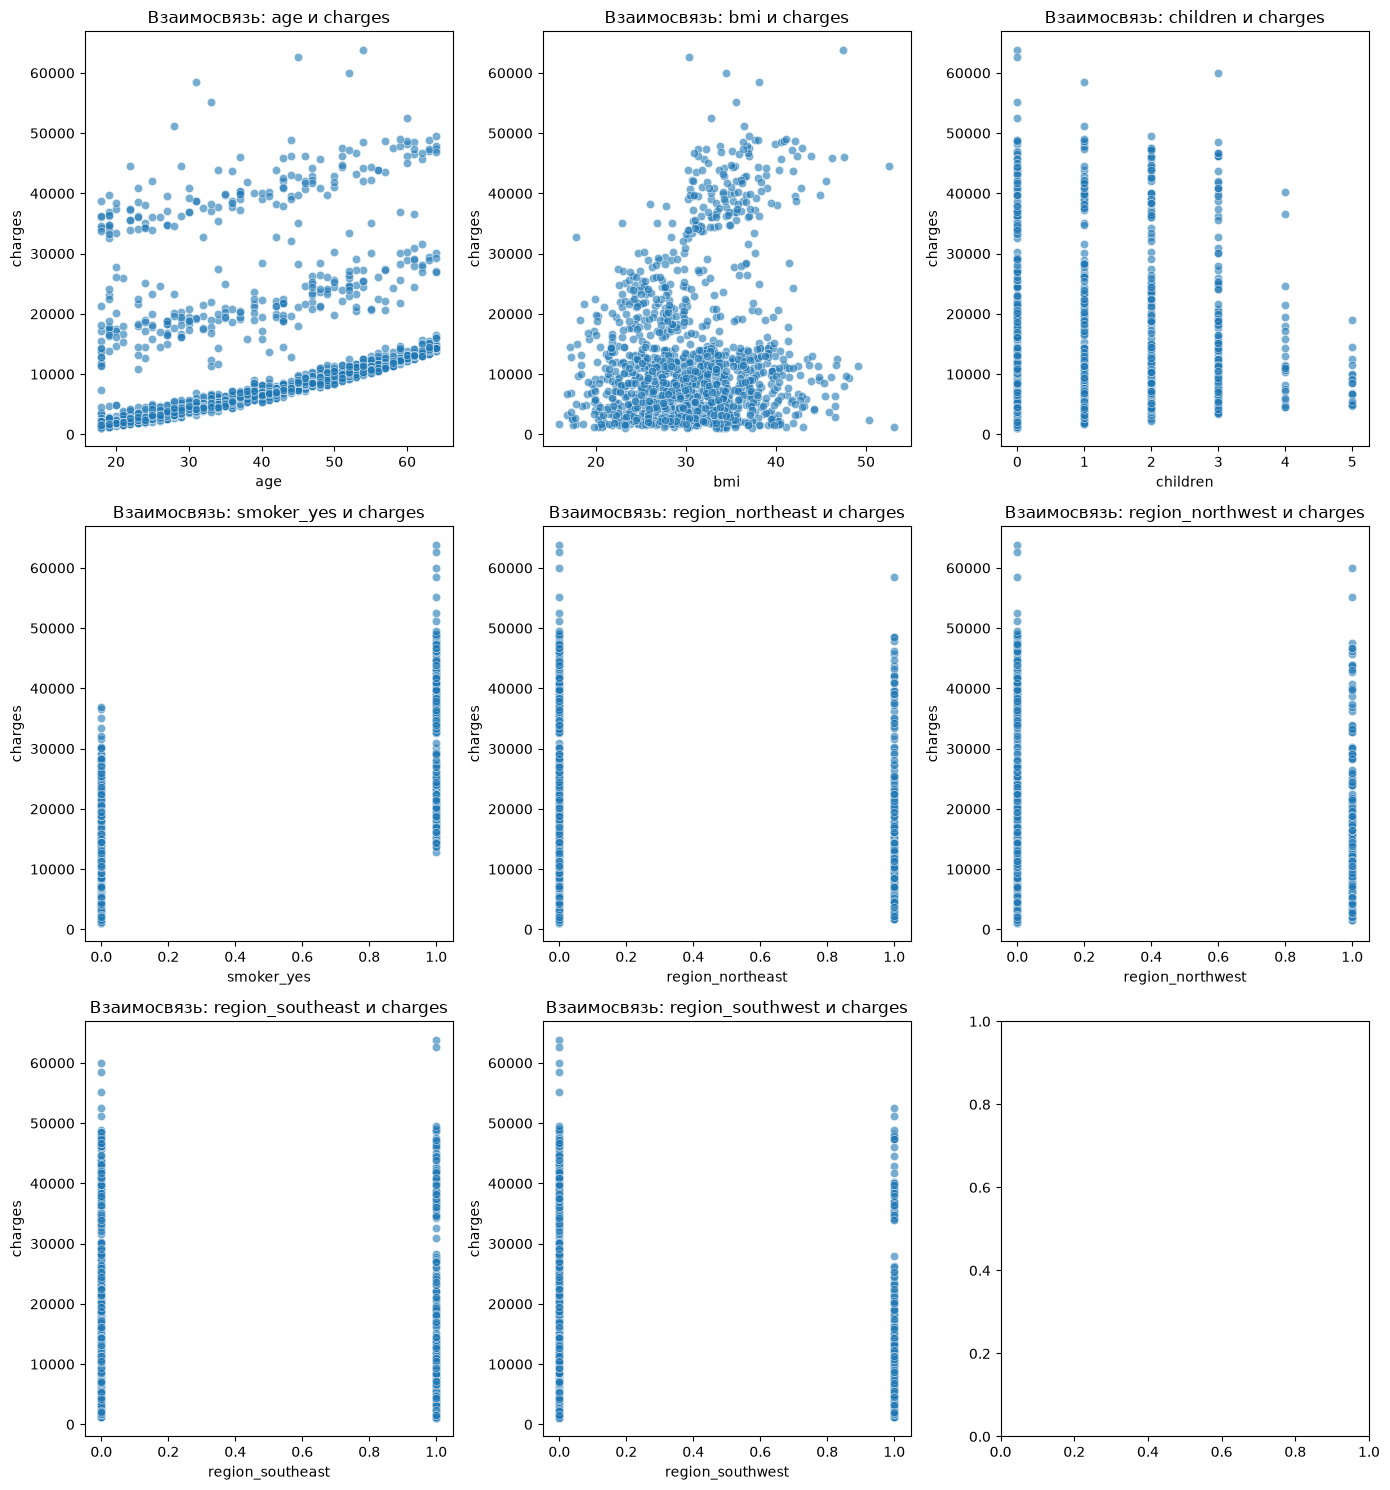

In [255]:
features_to_plot = ['age', 'bmi', 'children', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
target = 'charges'

fig, axes = plt.subplots(3, 3, figsize=(14, 15))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.scatterplot(data=df_encoded, x=feature, y=target, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Взаимосвязь: {feature} и {target}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()

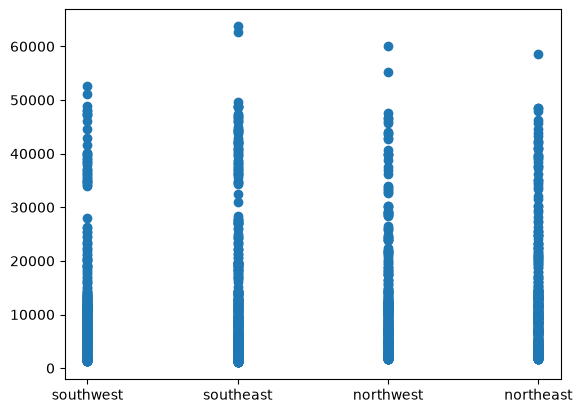

In [256]:
# Глянем отдельно на region из иригинального датафрейма
plt.scatter(data = df, x = "region", y = "charges")
plt.show()


Связи страховки с регионом не наблюдается.

Видна связь размера страховки с возрастом, курением, количеством детей.

Совсем небольшая связь наблюдается с bmi

### Разделите датасет на обучающую и тестовую выборки

In [257]:
def split_train_test(df, features_col, target_col, to_scale = False):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    if to_scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [258]:
target_col = ['charges']
features_col = ['age', 'bmi', 'children', 'smoker_yes']
X_train, X_test, y_train, y_test = split_train_test(df_encoded, features_col, target_col)


### Сделайте масштабирование объясняющих переменных

In [259]:
X_train_scaled, X_test_scaled, y_train, y_test = split_train_test(df_encoded, features_col, target_col, to_scale = True)


### Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающей выборке

Возникла идея собрать ваши функции в класс, который создает и визуализирует модели, чтобы потом была возможность все это сравнить и выбрать лучшее

In [260]:
class ML_insurance:
    def __init__(self, df, features_col, show = True,
                 model_kind='linear', to_scale=False, random_state=42,
                 test_size=0.33, target_col='charges', alpha=0.1):
        self.df = df
        self.features_col = features_col
        self.model_kind = model_kind
        self.target_col = target_col
        self.test_size = test_size
        self.random_state = random_state

        if self.model_kind in ('lasso', 'ridge'):
            to_scale = True

        # сразу готовим данные и обучаем
        self.split_train_test(to_scale=to_scale)
        self.model = self.train_model(kind=model_kind, alpha=alpha)
        self.y_pred = self.model.predict(self.X_test)
        if show is True:
            self.visualize_prediction(self.y_test, self.y_pred)
            self.show_metrics(self.y_test, self.y_pred)

    def split_train_test(self, to_scale=False):
        X = self.df[self.features_col]
        y = self.df[self.target_col]
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )
        if to_scale:
            self.scaler = StandardScaler()
            self.X_train = self.scaler.fit_transform(self.X_train)
            self.X_test = self.scaler.transform(self.X_test)

    def train_model(self, kind='linear', alpha=0.1):
        if kind == 'linear':
            model = LinearRegression()
        elif kind == 'lasso':
            model = Lasso(alpha=alpha)
        elif kind == 'ridge':
            model = Ridge(alpha=alpha)
        else:
            raise ValueError(kind)
        model.fit(self.X_train, self.y_train)
        return model

    def visualize_prediction(self, y_true, y_pred):
        fig, ax = plt.subplots(1,1, figsize = (5,5))
        sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
        sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
        ax.set_title(f"значения y ({self.model_kind}, random={self.random_state}, {self.features_col})")
        ax.set_xlabel('true y')
        ax.set_ylabel('pred y')
        plt.show()

    def show_metrics(self, y_true, y_pred):
        print('Среднее значение Y: ', np.mean(y_true))
        print('Среднеквадратическое отклонение Y: ', np.std(y_true, axis = 0))
        print('MSE: ', mean_squared_error(y_true, y_pred))
        print('RMSE: ', root_mean_squared_error(y_true, y_pred))
        print('MAE: ', mean_absolute_error(y_true, y_pred))
        print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
        print('R2: ', r2_score(y_true, y_pred))

# features_col = ['age', 'bmi', 'children', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


Обучим модельи на разных признаках с разными параметрами

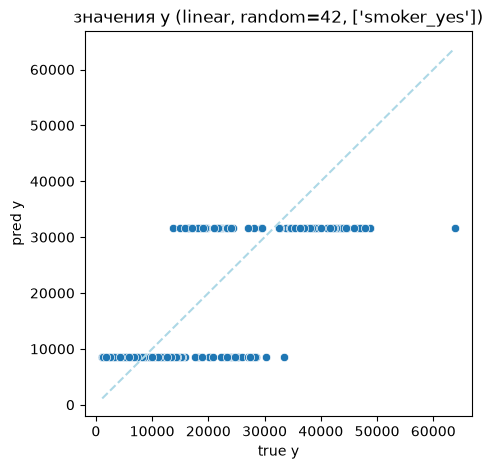

Среднее значение Y:  13048.923798052034
Среднеквадратическое отклонение Y:  12105.563015065558
MSE:  52765108.7474863
RMSE:  7263.959577770674
MAE:  5594.498000714892
MAPE:  0.8648861389876085
R2:  0.6399383626839901


In [261]:
ml = list()
ml.append (ML_insurance(df_encoded, ['smoker_yes'], model_kind='linear' ))

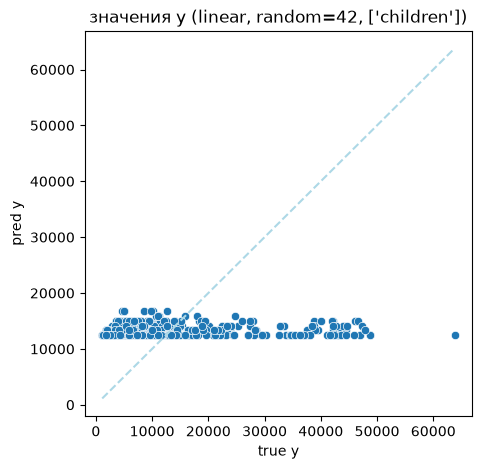

Среднее значение Y:  13048.923798052034
Среднеквадратическое отклонение Y:  12105.563015065558
MSE:  146855625.3878712
RMSE:  12118.400281715041
MAE:  9222.568548267456
MAPE:  1.5049389470049268
R2:  -0.0021220117118117


In [262]:
ml.append (ML_insurance(df_encoded, ['children',], model_kind='linear' ))

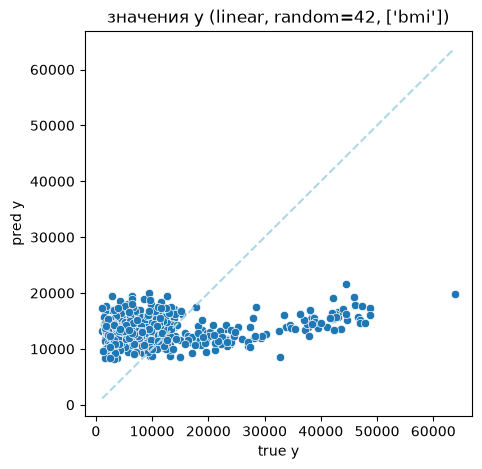

Среднее значение Y:  13048.923798052034
Среднеквадратическое отклонение Y:  12105.563015065558
MSE:  139577876.3244439
RMSE:  11814.308118736531
MAE:  9311.779595782731
MAPE:  1.5406699252056466
R2:  0.04754031830049055


In [263]:
ml.append (ML_insurance(df_encoded, ['bmi',], model_kind='linear' ))

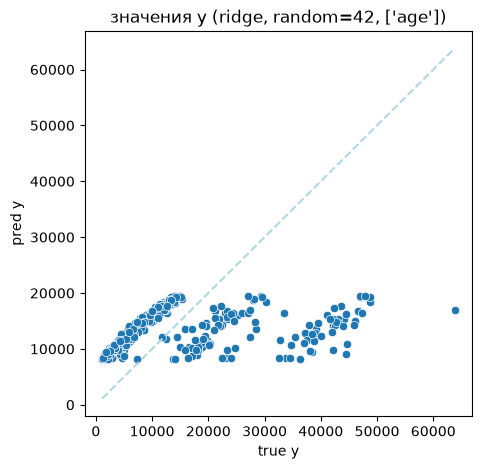

Среднее значение Y:  13048.923798052034
Среднеквадратическое отклонение Y:  12105.563015065558
MSE:  131694422.57929775
RMSE:  11475.81903740634
MAE:  9068.496337534963
MAPE:  1.1948688234271414
R2:  0.10133589137068888


In [264]:
ml.append (ML_insurance(df_encoded, ['age',], model_kind='ridge' ))

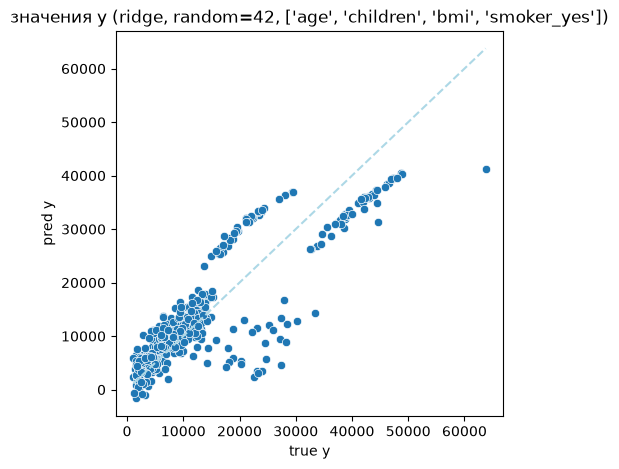

Среднее значение Y:  13048.923798052034
Среднеквадратическое отклонение Y:  12105.563015065558
MSE:  35299844.0416131
RMSE:  5941.367186230212
MAE:  4211.019358122935
MAPE:  0.44118261545086823
R2:  0.7591188581937963


In [265]:
ml.append (ML_insurance(df_encoded, ['age','children','bmi', 'smoker_yes'], model_kind='ridge' ))

Усложним с помощью LLM, сделав возможность обучать и сравнивать сразу много моделей

**Дальнейшее усложнение уже не имеет отношения к ДЗ, это я больше для себя**

In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)


class ML_insuranceLLM:
    def __init__(self, df, features_col, cat_cols=None, show=False,
                 model_kind='linear', to_scale=False, random_state=42,
                 test_size=0.33, target_col='charges', alpha=0.1):
        self.df = df
        self.features_col = features_col
        self.model_kind = model_kind
        self.target_col = target_col
        self.test_size = test_size
        self.random_state = random_state
        self.alpha = alpha

        if self.model_kind not in ('linear', 'lasso', 'ridge'):
            raise ValueError(f'Unknown model kind: {self.model_kind}')

        # автоопределение категориальных колонок
        if cat_cols is None:
            cat_cols = [c for c in features_col
                        if not pd.api.types.is_numeric_dtype(df[c])]
        self.cat_cols = list(cat_cols)
        self.num_cols = [c for c in features_col if c not in self.cat_cols]

        # lasso/ridge — масштабируем принудительно
        if self.model_kind in ('lasso', 'ridge'):
            to_scale = True
        self.to_scale = to_scale

        self.split_train_test()
        self.model = self.train_model(kind=self.model_kind, alpha=alpha)
        self.y_pred = self.model.predict(self.X_test)

        if show:
            self.visualize_prediction()
            self.show_metrics()

    # ---------- препроцессор ----------
    def _build_preprocessor(self):
        num_pipe = Pipeline([('scaler', StandardScaler())]) if self.to_scale else 'passthrough'

        transformers = []
        if self.num_cols:
            transformers.append(('num', num_pipe, self.num_cols))
        if self.cat_cols:
            transformers.append(
                ('cat',
                 OneHotEncoder(handle_unknown='ignore',
                               drop='first',
                               sparse_output=False),
                 self.cat_cols)
            )
        return ColumnTransformer(transformers, remainder='drop')

    def split_train_test(self):
        X = self.df[self.features_col]
        y = self.df[self.target_col]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=self.test_size, random_state=self.random_state
        )

        # препроцессор обучаем только на train
        self.preprocessor = self._build_preprocessor()
        self.X_train = self.preprocessor.fit_transform(self.X_train)
        self.X_test = self.preprocessor.transform(self.X_test)

    def train_model(self, kind='linear', alpha=0.1):
        if kind == 'linear':           
            model = LinearRegression()
        elif kind == 'lasso':
            model = Lasso(alpha=alpha, max_iter=10000)
        elif kind == 'ridge':
            model = Ridge(alpha=alpha)
        else:
            raise ValueError(kind)
        model.fit(self.X_train, self.y_train)
        return model

    # ---------- визуализация ----------
    def visualize_prediction(self, y_true=None, y_pred=None, ax=None, label=None):
        y_true = self.y_test if y_true is None else y_true
        y_pred = self.y_pred if y_pred is None else y_pred
        if ax is None:
            _, ax = plt.subplots(1, 1, figsize=(5, 5))

        yt = np.ravel(y_true)
        yp = np.ravel(y_pred)

        sns.scatterplot(x=yt, y=yp, ax=ax, alpha=0.5,
                        label=label or self.model_kind)
        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lims, lims, linestyle='--', color='lightblue')

        ax.set_title(f'{self.model_kind} | n_feat={len(self.features_col)} | '
                     f'random={self.random_state} | alpha={self.alpha}')
        ax.set_xlabel('true y')
        ax.set_ylabel('pred y')
        return ax

    # ---------- метрики ----------
    def get_metrics(self, y_true=None, y_pred=None):
        y_true = self.y_test if y_true is None else y_true
        y_pred = self.y_pred if y_pred is None else y_pred

        mse = mean_squared_error(y_true, y_pred)
        return {
            'model': self.model_kind,
            'features_str': self.features_col[-1],
            'alpha': self.alpha,
            'n_features': len(self.features_col),
            'to_scale': self.to_scale,
            'mean_y': float(np.mean(y_true)),
            'std_y': float(np.std(y_true)),
            'MSE': mse,
            'RMSE': float(np.sqrt(mse)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'MAPE': mean_absolute_percentage_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred),
        }

    def show_metrics(self, y_true=None, y_pred=None):
        for k, v in self.get_metrics(y_true, y_pred).items():
            print(f'{k}: {v}')


In [267]:
# Координатор: список моделей + сравнение
def compare_models(models, title='Model comparison', figsize_per=4):
    """
    models: список объектов ML_insurance
    """
    n = len(models)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(figsize_per * ncols, figsize_per * nrows),
                             squeeze=False)
    axes = axes.ravel()

    for ax, m in zip(axes, models):
        m.visualize_prediction(ax=ax)

    # скрыть пустые оси
    for ax in axes[n:]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    # таблица метрик
    metrics_df = pd.DataFrame([m.get_metrics() for m in models])
    return metrics_df

Обучим с разными показателями на разных типах обучения на стандартной спецификации (randon_state = 42)

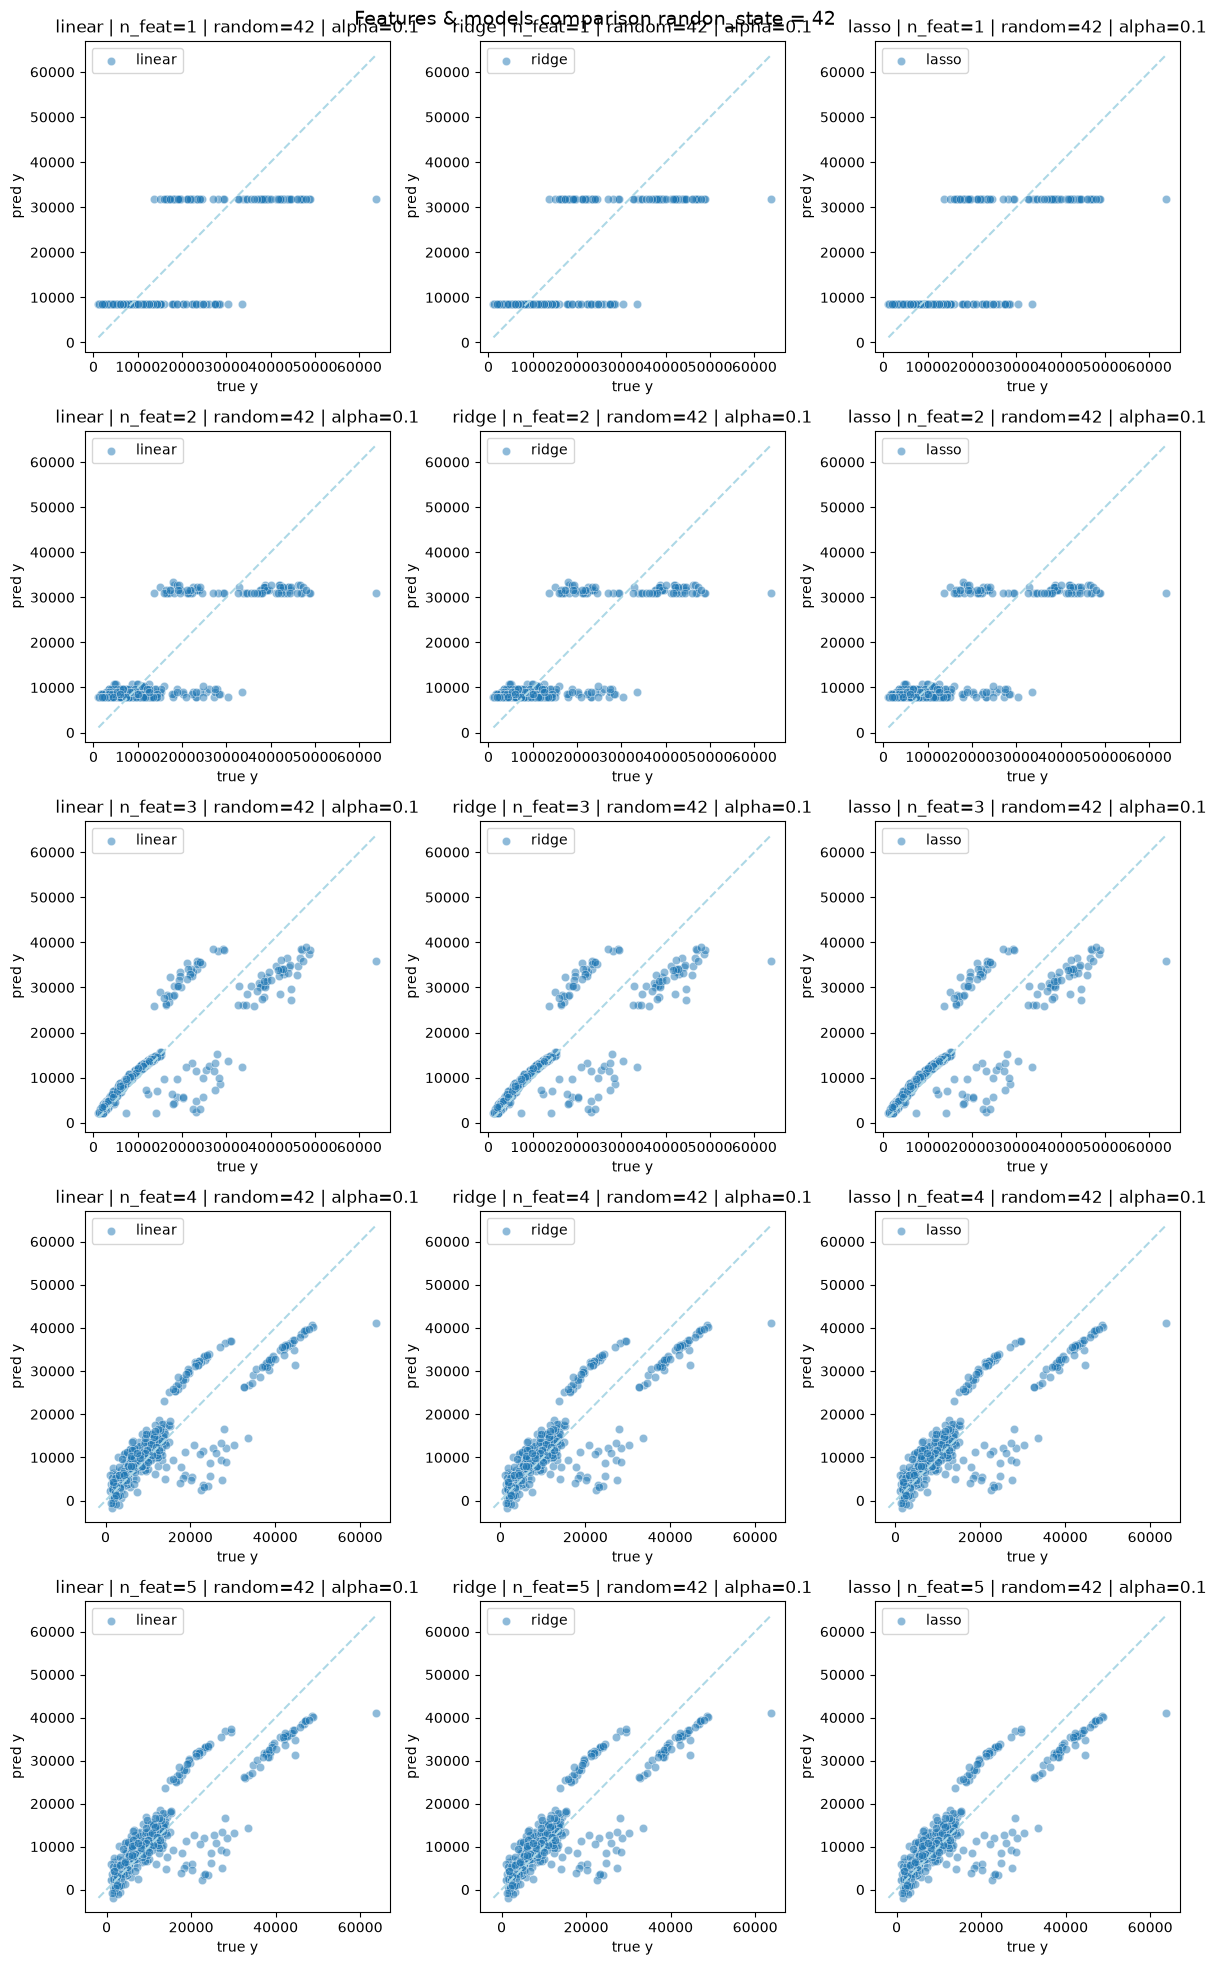

In [283]:
# Показатели для обучения
features_list = [
    ['smoker_yes'],
    ['smoker_yes', 'children'],
    ['smoker_yes', 'children', 'age'],
    ['smoker_yes', 'children', 'age', 'bmi'],
    ['smoker_yes', 'children', 'age', 'bmi','region_northeast']
]
# features_to_plot = ['age', 'bmi', 'children', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


# Обучим на стандартной спецификации (у нас по умолчанию randon_state = 42)
models = []
for feats in features_list:
    for kind in ['linear', 'ridge', 'lasso']:
        models.append(ML_insuranceLLM(df_encoded, features_col=feats,
                                   model_kind=kind, alpha=0.1))

metrics_df = compare_models(models, title='Features & models comparison randon_state = 42')

In [269]:
models[3].get_metrics()

{'model': 'linear',
 'features_str': 'smoker_yes+children',
 'alpha': 0.1,
 'n_features': 2,
 'to_scale': False,
 'mean_y': 13048.923798052034,
 'std_y': 12105.563015065558,
 'MSE': 52127996.85726504,
 'RMSE': 7219.972081474072,
 'MAE': 5582.196901801965,
 'MAPE': 0.8379674405561626,
 'R2': 0.6442859240894709}

Визуализация метрик нескольких моделей (несколько вариантов)

In [ ]:
def plot_metrics(models, metrics=None, figsize=(14, 8)):
    """
    models: список ML_insurance
    metrics: список метрик для отрисовки. По умолчанию — все, кроме служебных.

    Группы по 3 столбика (linear/ridge/lasso для одного набора признаков)
    выделяются отдельным цветом.
    """
    df = pd.DataFrame([m.get_metrics() for m in models])


    # номер группы: определяем по смене n_features (каждый набор признаков — своя группа)
    df['group'] = (df['n_features'] != df['n_features'].shift(1)).cumsum() - 1
    df['label'] = df['model'] + '_' + df['group'].astype(str)

    if metrics is None:
        # метрики, которые имеет смысл рисовать
        metrics = ['MSE', 'RMSE', 'MAE', 'MAPE', 'R2']

    n = len(metrics)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # палитра для групп (достаточно 5 цветов для 5 наборов признаков)
    group_palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

    for ax, metric in zip(axes, metrics):
        colors = [group_palette[g % len(group_palette)] for g in df['group']]
        bars = ax.bar(df['label'], df[metric], color=colors, alpha=0.85)

        # подписи значений
        for b, v in zip(bars, df[metric]):
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
                    f'{v:.3g}', ha='center', va='bottom', fontsize=8)

        ax.set_title(metric)
        ax.tick_params(axis='x', rotation=60)
        ax.grid(axis='y', alpha=0.3)

    for ax in axes[n:]:
        ax.axis('off')

    # легенда: одна метка на группу
    from matplotlib.patches import Patch
    n_groups = df['group'].nunique()
    legend_elements = [
        Patch(facecolor=group_palette[g % len(group_palette)], alpha=0.85,
              label=f'Набор признаков {g}')
        for g in range(n_groups)
    ]
    axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8,
                   title='Группы')

    fig.suptitle('Сравнение метрик моделей', fontsize=14)
    plt.tight_layout()
    plt.show()

    return df


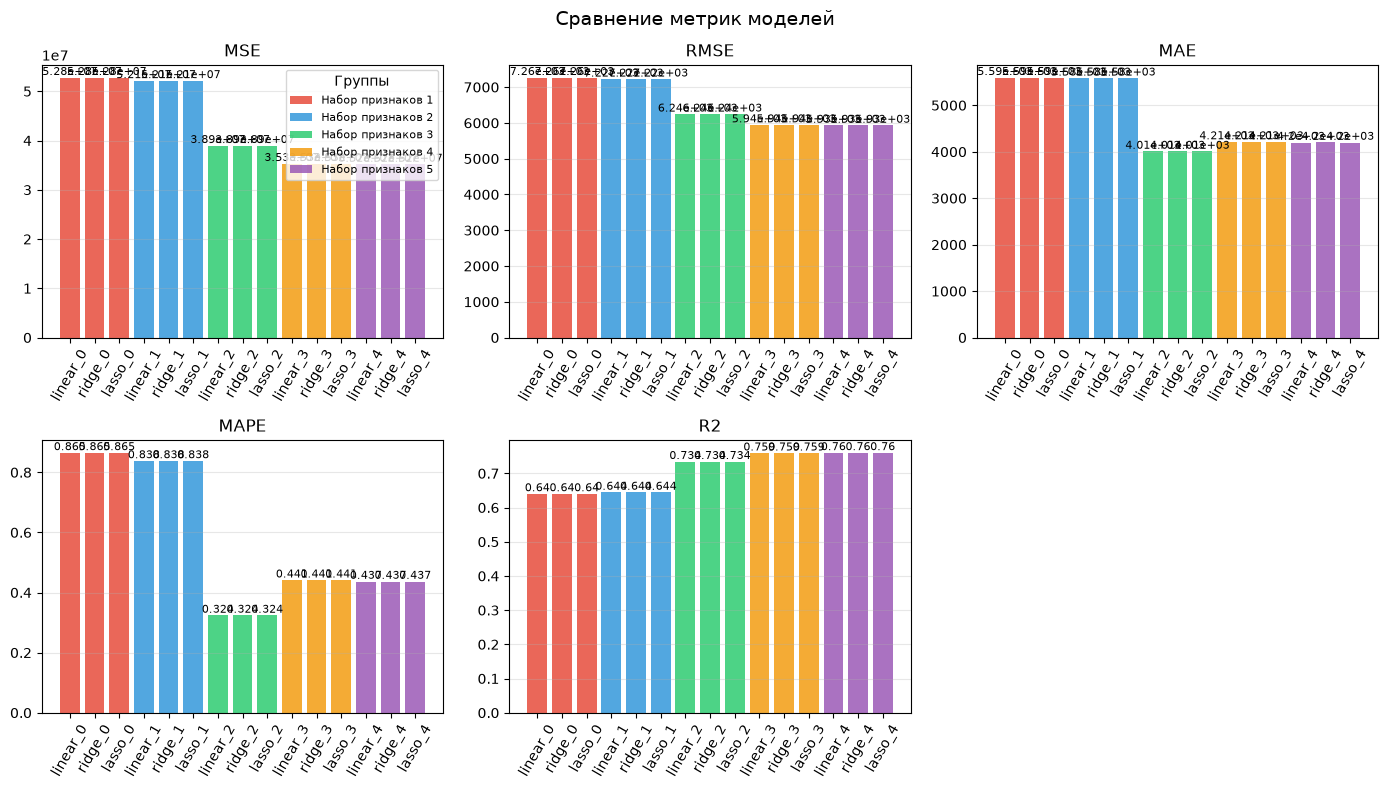

In [344]:
metrics_df_plot = plot_metrics(models)

Вариант 4: тепловая карта метрик

In [294]:
def metrics_heatmap(models, figsize=(10, 8)):
    df = pd.DataFrame([m.get_metrics() for m in models])
    df['label'] = df['model'] + '_' + df.index.astype(str)

    cols = ['MSE', 'RMSE', 'MAE', 'MAPE', 'R2']
    # нормируем по столбцу в [0,1]
    norm = df[cols].copy()
    for c in cols:
        v = norm[c]
        norm[c] = (v - v.min()) / (v.max() - v.min() + 1e-12)
    norm['R2'] = 1 - norm['R2']  # для R2 меньше = лучше

    plt.figure(figsize=figsize)
    sns.heatmap(norm.set_index(df['label']),
                cmap='RdYlGn_r', annot=df[cols].round(3).values,
                fmt='', cbar_kws={'label': 'normalized (0=best)'})
    plt.title('Метрики моделей (значение в ячейке — реальное)')
    plt.tight_layout()
    plt.show()
    return df

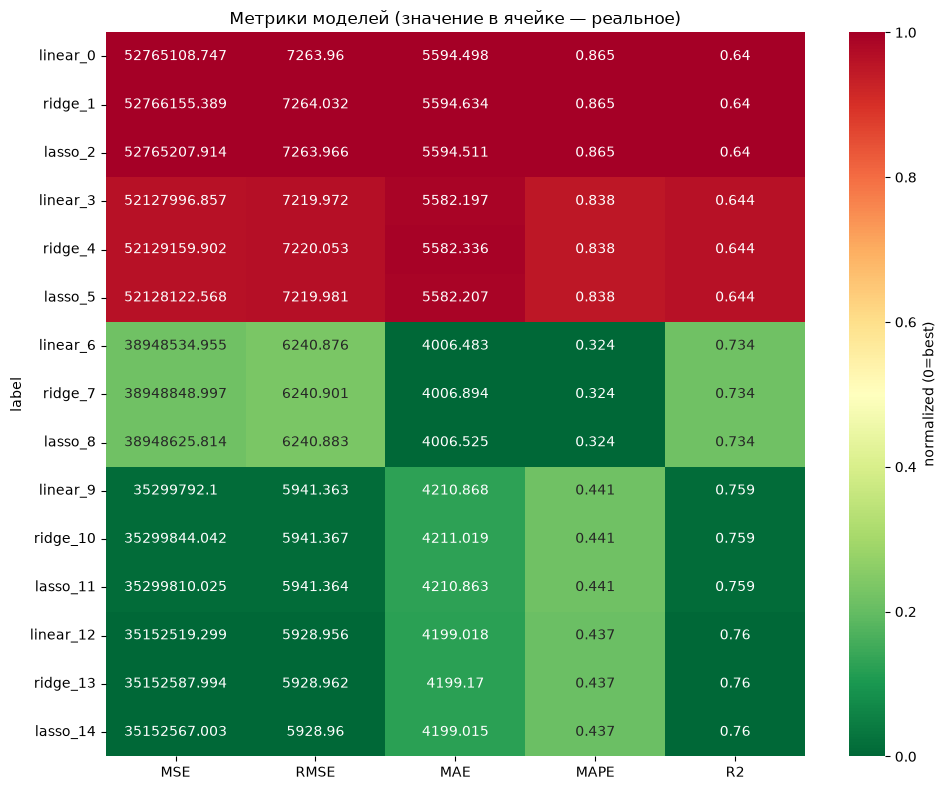

In [295]:
metrics_df_heatmap=metrics_heatmap(models)

Оставим только зеленые списки критериев, остальные не отражают ожидания

Также почему то нет разницы между типами обучения ('linear', 'ridge', 'lasso'). Видимо где то ошибка в скрипте

Оставим только одну и Обучим на других спецификациях

### Проверка на устойчивость

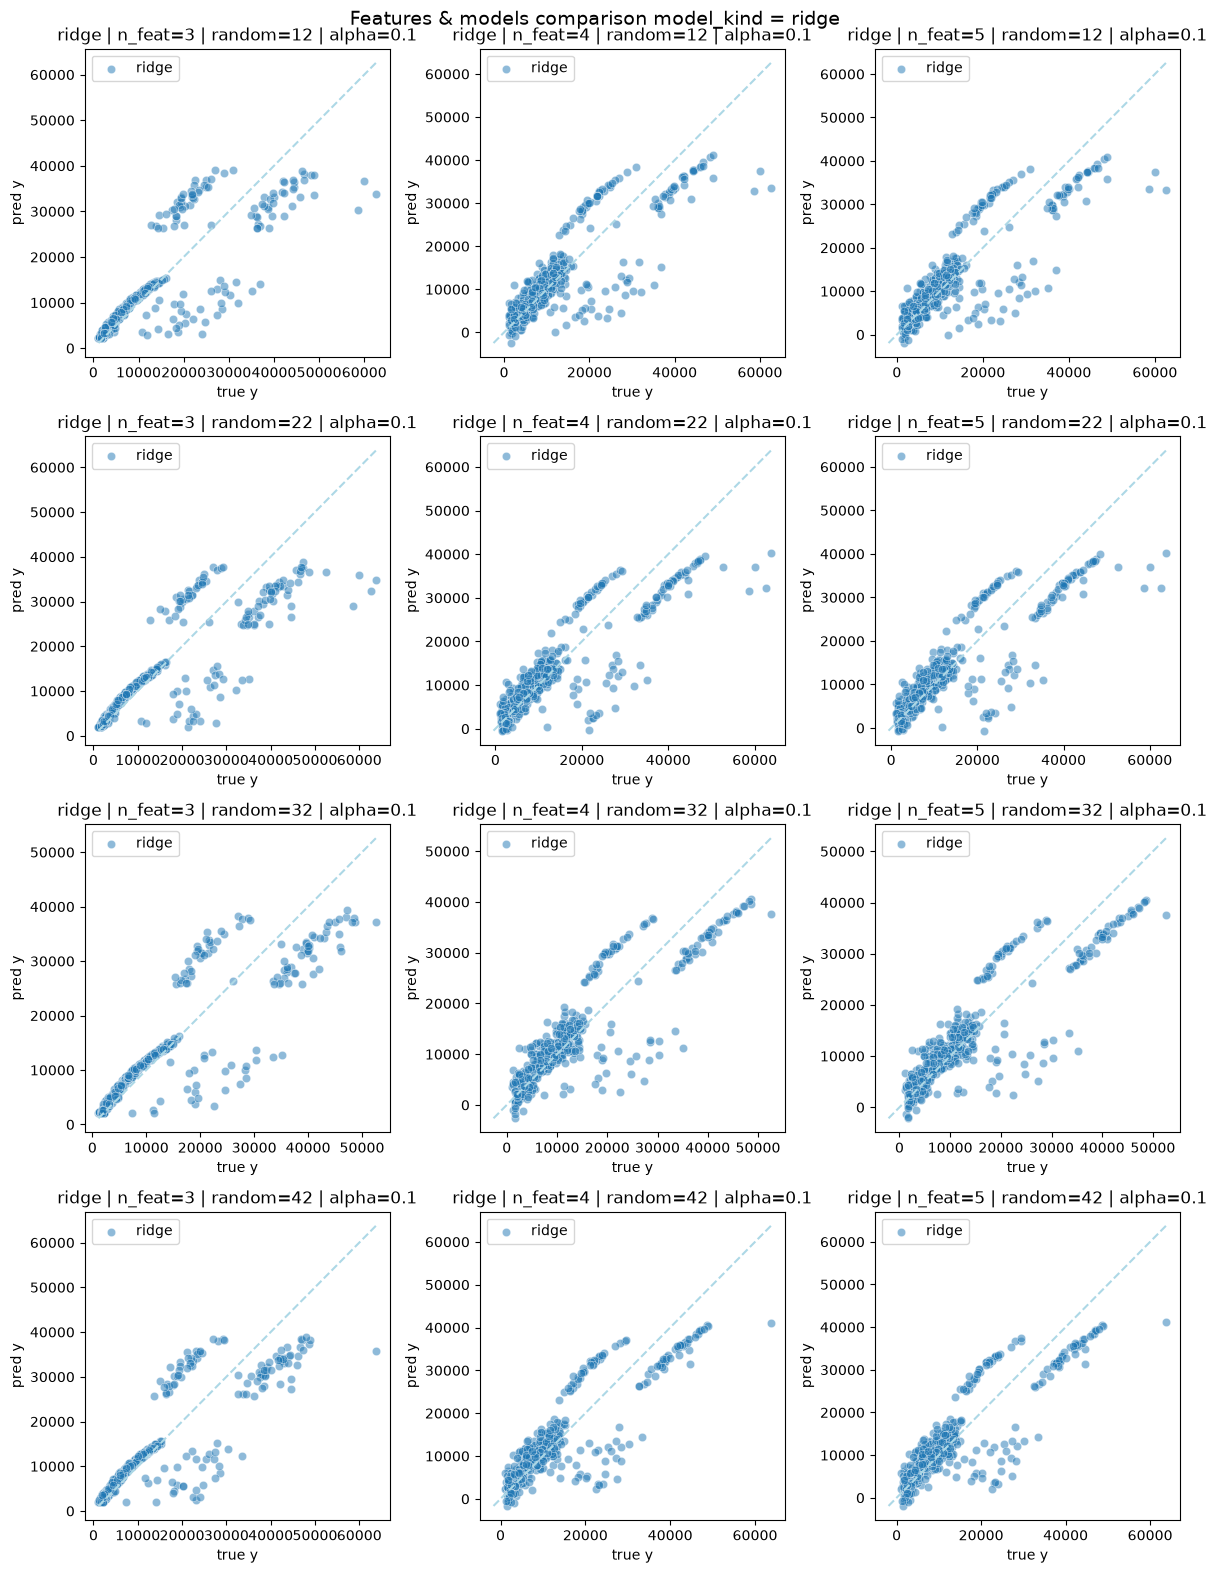

In [296]:
features_list = [
    ['smoker_yes', 'children', 'age'],
    ['smoker_yes', 'children', 'age', 'bmi'],
    ['smoker_yes', 'children', 'age', 'bmi','region_northeast']
]
# features = ['age', 'bmi', 'children', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


# Обучим на других спецификациях (у нас по умолчанию randon_state = 42) и на  model_kind='ridge'
models = []
for random_state in [12, 22, 32, 42]:
    for feats in features_list:
        models.append(ML_insuranceLLM(df_encoded, features_col=feats,
                                   model_kind='ridge', random_state = random_state))

metrics_df = compare_models(models, title=f'Features & models comparison model_kind = ridge')

где первый столбец - это первый набор параметров (['smoker_yes', 'children', 'age'])

а первая строка - randon_state = 12

Посмотрим метрики

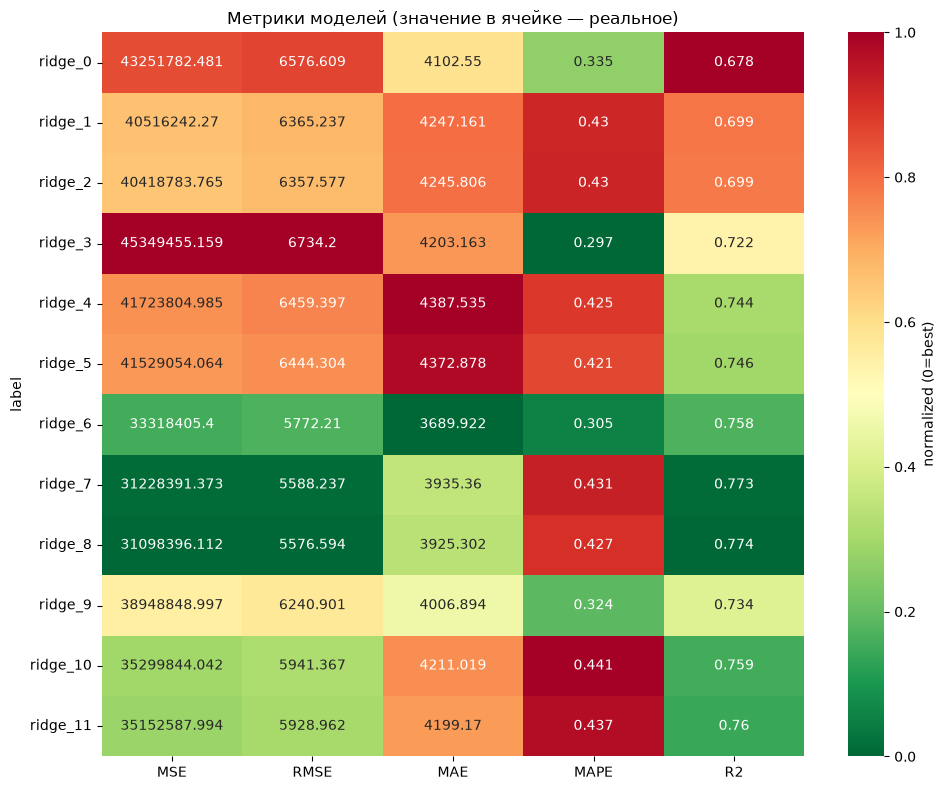

In [297]:
metrics_df_heatmap=metrics_heatmap(models)

Здесь и ниже первая четверка - это 4 спецификации первого набора параметров, вторая - второго и так далее

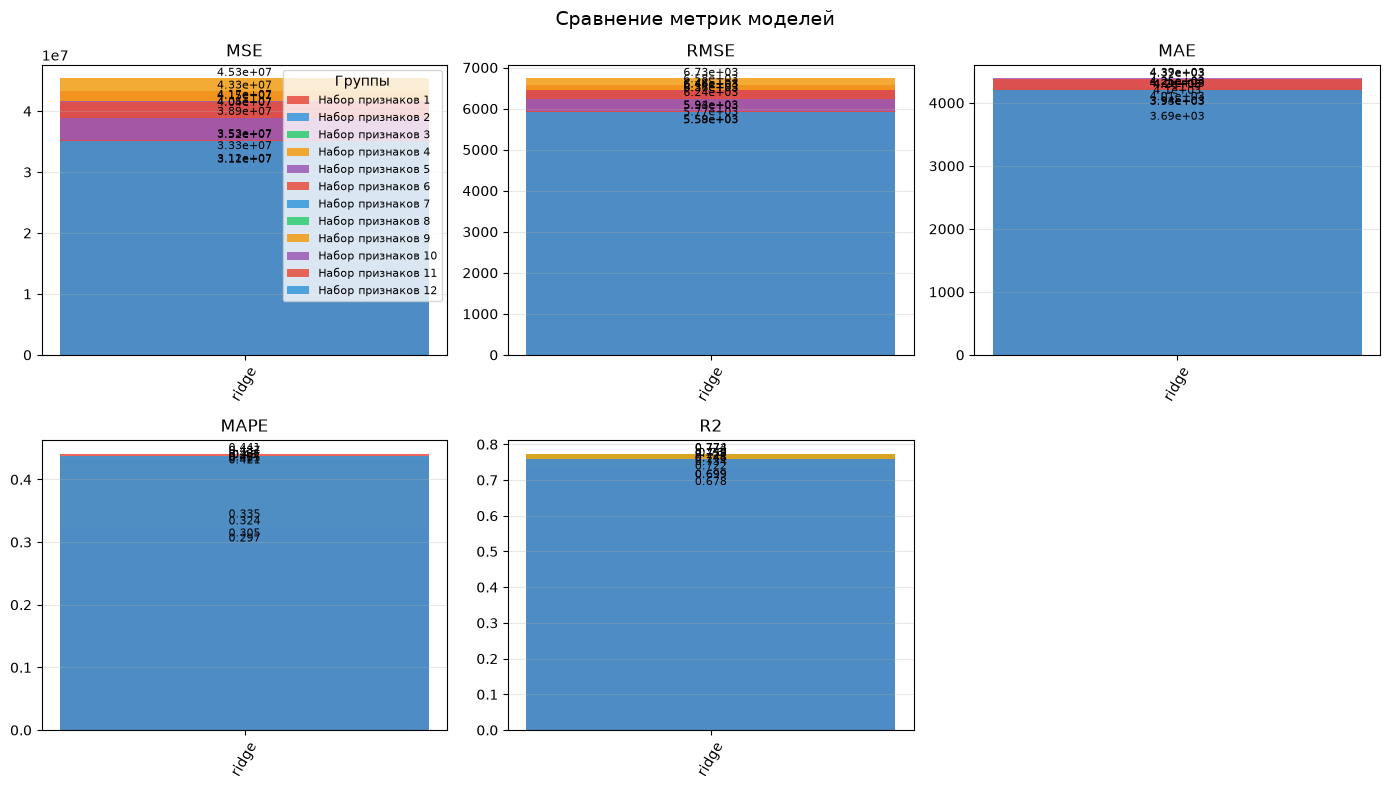

In [298]:
metrics_df_plot = plot_metrics(models)

Первый набор лучше по MAPE, но хуже по другим.

Третий чуть отличается от второго в лучшую сторону. 

Однозначного вывода нет.
